Project: **E-Commerce Sales & Customer Analysis**

Objective:
Analyze customer behavior, sales performance,
product performance, payments, reviews, and
delivery operations.

Source:
**Olist Brazilian E-Commerce Public Dataset**

In [ ]:
import pandas as pd
import numpy as np
import os


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_path = "/content/olist_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
for root, dirs, files_list in os.walk(extract_path):
    for file in files_list:
        print(os.path.join(root, file))

/content/olist_data/olist_sellers_dataset.csv
/content/olist_data/olist_order_items_dataset.csv
/content/olist_data/olist_order_reviews_dataset.csv
/content/olist_data/product_category_name_translation.csv
/content/olist_data/olist_orders_dataset.csv
/content/olist_data/olist_products_dataset.csv
/content/olist_data/olist_geolocation_dataset.csv
/content/olist_data/olist_order_payments_dataset.csv
/content/olist_data/olist_customers_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [ ]:
DATA_PATH = "/content/olist_data/"

customers = pd.read_csv(
    DATA_PATH + "olist_customers_dataset.csv"
)

geolocation = pd.read_csv(
    DATA_PATH + "olist_geolocation_dataset.csv"
)

order_items = pd.read_csv(
    DATA_PATH + "olist_order_items_dataset.csv"
)

payments = pd.read_csv(
    DATA_PATH + "olist_order_payments_dataset.csv"
)

reviews = pd.read_csv(
    DATA_PATH + "olist_order_reviews_dataset.csv"
)

orders = pd.read_csv(
    DATA_PATH + "olist_orders_dataset.csv"
)

products = pd.read_csv(
    DATA_PATH + "olist_products_dataset.csv"
)

sellers = pd.read_csv(
    DATA_PATH + "olist_sellers_dataset.csv"
)

category_translation = pd.read_csv(
    DATA_PATH + "product_category_name_translation.csv"
)

In [ ]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"{name:25} {df.shape}")

customers                 (99441, 5)
geolocation               (1000163, 5)
order_items               (112650, 7)
payments                  (103886, 5)
reviews                   (99224, 7)
orders                    (99441, 8)
products                  (32951, 9)
sellers                   (3095, 4)
category_translation      (71, 2)


In [ ]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)
    display(df.head())


CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



ORDER_ITEMS


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



SELLERS


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



CATEGORY_TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    print("Columns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)


CUSTOMERS
Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Data Types:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

GEOLOCATION
Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

Data Types:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

ORDER_ITEMS
Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Data Types:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  flo

**Missing values**

In [ ]:
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print("=" * 60)

    missing = pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Missing Percentage": (
            df.isnull().sum() / len(df) * 100
        ).round(2)
    })

    display(missing[missing["Missing Values"] > 0])


CUSTOMERS


,Missing Values,Missing Percentage



GEOLOCATION


,Missing Values,Missing Percentage



ORDER_ITEMS


...

,Missing Values,Missing Percentage
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01



SELLERS


,Missing Values,Missing Percentage



CATEGORY_TRANSLATION


,Missing Values,Missing Percentage


**Duplicate records**

In [ ]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("Total rows:", len(df))
    print("Exact duplicate rows:", df.duplicated().sum())


CUSTOMERS
Total rows: 99441
Exact duplicate rows: 0

GEOLOCATION
Total rows: 1000163
Exact duplicate rows: 261831

ORDER_ITEMS
Total rows: 112650
Exact duplicate rows: 0

PAYMENTS
Total rows: 103886
Exact duplicate rows: 0

REVIEWS
Total rows: 99224
Exact duplicate rows: 0

ORDERS
Total rows: 99441
Exact duplicate rows: 0

PRODUCTS
Total rows: 32951
Exact duplicate rows: 0

SELLERS
Total rows: 3095
Exact duplicate rows: 0

CATEGORY_TRANSLATION
Total rows: 71
Exact duplicate rows: 0


In [ ]:
for name, df in datasets.items():
    print(f"\n{'=' * 50}")
    print(name.upper())

    display(df.describe().T)


CUSTOMERS


,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,99441.0,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0



GEOLOCATION


,count,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163.0,36574.166466,30549.335710,1001.000000,11075.000000,26530.000000,63504.000000,99990.000000
geolocation_lat,1000163.0,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.979620,45.065933
geolocation_lng,1000163.0,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394



ORDER_ITEMS


...

,count,mean,std,min,25%,50%,75%,max
product_name_lenght,32341.0,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0
product_description_lenght,32341.0,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0
product_photos_qty,32341.0,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0
product_weight_g,32949.0,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32949.0,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0
product_height_cm,32949.0,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0
product_width_cm,32949.0,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0



SELLERS


,count,mean,std,min,25%,50%,75%,max
seller_zip_code_prefix,3095.0,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0



CATEGORY_TRANSLATION


,count,unique,top,freq
product_category_name,71,71,beleza_saude,1
product_category_name_english,71,71,health_beauty,1


**order status**

In [ ]:
display(
    orders["order_status"]
    .value_counts(dropna=False)
    .rename_axis("Order Status")
    .reset_index(name="Number of Orders")
)

,Order Status,Number of Orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


**order date range**

In [ ]:
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

print("First order:", orders["order_purchase_timestamp"].min())
print("Last order:", orders["order_purchase_timestamp"].max())

First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18


# **relationships between tables**

**Orders → Customers**

In [ ]:
missing_customers = (
    ~orders["customer_id"].isin(customers["customer_id"])
).sum()

print("Orders with missing customer references:", missing_customers)

Orders with missing customer references: 0


**Order Items → Orders**

In [ ]:
missing_orders = (
    ~order_items["order_id"].isin(orders["order_id"])
).sum()

print("Order items with missing order references:", missing_orders)

Order items with missing order references: 0


**Order Items → Products**

In [ ]:
missing_products = (
    ~order_items["product_id"].isin(products["product_id"])
).sum()

print("Order items with missing product references:", missing_products)

Order items with missing product references: 0


**Order Items → Sellers**

In [ ]:
missing_sellers = (
    ~order_items["seller_id"].isin(sellers["seller_id"])
).sum()

print("Order items with missing seller references:", missing_sellers)

Order items with missing seller references: 0


**Payments → Orders**

In [ ]:
missing_payment_orders = (
    ~payments["order_id"].isin(orders["order_id"])
).sum()

print("Payments with missing order references:", missing_payment_orders)

Payments with missing order references: 0


**Reviews → Orders**

In [ ]:
missing_review_orders = (
    ~reviews["order_id"].isin(orders["order_id"])
).sum()

print("Reviews with missing order references:", missing_review_orders)

Reviews with missing order references: 0


# **Check orders without associated records**

**Orders without items, payments, or reviews**

In [ ]:
order_ids = set(orders["order_id"])

orders_without_items = len(
    order_ids - set(order_items["order_id"])
)

orders_without_payments = len(
    order_ids - set(payments["order_id"])
)

orders_without_reviews = len(
    order_ids - set(reviews["order_id"])
)

print("Orders without items:", orders_without_items)
print("Orders without payments:", orders_without_payments)
print("Orders without reviews:", orders_without_reviews)

Orders without items: 775
Orders without payments: 1
Orders without reviews: 768


**Validate prices, freight, and payments**

In [ ]:
print("Negative product prices:",
      (order_items["price"] < 0).sum())

print("Zero product prices:",
      (order_items["price"] == 0).sum())

print("Negative freight values:",
      (order_items["freight_value"] < 0).sum())

print("Negative payment values:",
      (payments["payment_value"] < 0).sum())

print("Zero payment values:",
      (payments["payment_value"] == 0).sum())

Negative product prices: 0
Zero product prices: 0
Negative freight values: 0
Negative payment values: 0
Zero payment values: 9


**Validate review scores**

In [ ]:
print("Review scores:")
print(sorted(reviews["review_score"].dropna().unique()))

invalid_scores = ~reviews["review_score"].between(1, 5)

print("Invalid review scores:", invalid_scores.sum())

Review scores:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Invalid review scores: 0


**Summary of all nine tables**

In [ ]:
quality_summary = []

for name, df in datasets.items():
    quality_summary.append({
        "Table": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing Cells": int(df.isnull().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum()),
        "Memory (MB)": round(
            df.memory_usage(deep=True).sum() / (1024 ** 2), 2
        )
    })

quality_summary = pd.DataFrame(quality_summary)

display(quality_summary)

,Table,Rows,Columns,Missing Cells,Duplicate Rows,Memory (MB)
0,customers,99441,5,0,0,26.59
1,geolocation,1000163,5,0,261831,130.26
2,order_items,112650,7,0,0,35.99
3,payments,103886,5,0,0,16.23
4,reviews,99224,7,145903,0,39.12
5,orders,99441,8,4908,0,24.66
6,products,32951,9,2448,0,6.30
7,sellers,3095,4,0,0,0.59
8,category_translation,71,2,0,0,0.01


In [ ]:
quality_summary.to_csv(
    "/content/data_quality_summary.csv",
    index=False
)

print("Data quality summary saved successfully.")

Data quality summary saved successfully.


In [ ]:
for name, df in datasets.items():
    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if not missing.empty:
        print(f"\n{'=' * 60}")
        print(name.upper())
        print("=" * 60)

        missing_df = pd.DataFrame({
            "Missing Values": missing,
            "Missing Percentage": (
                missing / len(df) * 100
            ).round(2)
        })

        display(missing_df)


REVIEWS


,Missing Values,Missing Percentage
review_comment_title,87656,88.34
review_comment_message,58247,58.70



ORDERS


,Missing Values,Missing Percentage
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98



PRODUCTS


,Missing Values,Missing Percentage
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


In [ ]:
order_date_columns = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]

missing_dates_by_status = (
    orders.groupby("order_status")[order_date_columns]
    .agg(lambda x: x.isna().sum())
)

display(missing_dates_by_status)

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


In [ ]:
product_missing = products.isnull().sum()

product_missing = product_missing[
    product_missing > 0
]

display(
    product_missing
    .to_frame(name="Missing Values")
)

,Missing Values
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
print("Total geolocation records:", len(geolocation))

print(
    "Exact duplicate rows:",
    geolocation.duplicated().sum()
)

print(
    "Unique ZIP prefixes:",
    geolocation["geolocation_zip_code_prefix"].nunique()
)

print(
    "Unique latitude-longitude pairs:",
    geolocation[
        ["geolocation_lat", "geolocation_lng"]
    ].drop_duplicates().shape[0]
)

Total geolocation records: 1000163
Exact duplicate rows: 261831
Unique ZIP prefixes: 19015
Unique latitude-longitude pairs: 718463


In [ ]:
# Recalculate missing values directly from the current DataFrames

for name, df in datasets.items():
    total_missing = int(df.isnull().sum().sum())

    print(f"{name:25} | Missing cells: {total_missing:,}")

    if total_missing > 0:
        display(
            df.isnull()
            .sum()
            .loc[lambda x: x > 0]
            .to_frame("Missing Values")
        )

customers                 | Missing cells: 0
geolocation               | Missing cells: 0
order_items               | Missing cells: 0
payments                  | Missing cells: 0
reviews                   | Missing cells: 145,903


,Missing Values
review_comment_title,87656
review_comment_message,58247


orders                    | Missing cells: 4,908


,Missing Values
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965


products                  | Missing cells: 2,448


,Missing Values
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


sellers                   | Missing cells: 0
category_translation      | Missing cells: 0


In [ ]:
geo_summary = (
    geolocation
    .groupby("geolocation_zip_code_prefix")
    .agg(
        record_count=("geolocation_zip_code_prefix", "size"),
        unique_coordinates=(
            "geolocation_lat",
            "nunique"
        ),
        unique_longitudes=(
            "geolocation_lng",
            "nunique"
        )
    )
    .reset_index()
)

print("Total ZIP prefixes:", len(geo_summary))

print(
    "ZIP prefixes with multiple latitude values:",
    (geo_summary["unique_coordinates"] > 1).sum()
)

print(
    "ZIP prefixes with multiple longitude values:",
    (geo_summary["unique_longitudes"] > 1).sum()
)

display(
    geo_summary.sort_values(
        "record_count",
        ascending=False
    ).head(10)
)

Total ZIP prefixes: 19015
ZIP prefixes with multiple latitude values: 17781
ZIP prefixes with multiple longitude values: 17780


,geolocation_zip_code_prefix,record_count,unique_coordinates,unique_longitudes
6837,24220,1146,410,411
6838,24230,1102,327,327
9536,38400,965,746,745
8728,35500,907,726,726
4501,11680,879,726,726
6638,22631,832,141,142
8062,30140,810,379,380
4528,11740,788,666,666
9542,38408,773,600,599
7728,28970,743,582,583


In [ ]:
quality_summary = pd.DataFrame([
    {
        "Table": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing Cells": int(df.isnull().sum().sum()),
        "Exact Duplicate Rows": int(df.duplicated().sum())
    }
    for name, df in datasets.items()
])

quality_summary.to_csv(
    "/content/data_quality_summary.csv",
    index=False
)

display(quality_summary)

,Table,Rows,Columns,Missing Cells,Exact Duplicate Rows
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,orders,99441,8,4908,0
6,products,32951,9,2448,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [ ]:
# Verify missing values in the original DataFrames

for name, df in datasets.items():
    print(f"\n{name.upper()}")

    total_missing = int(df.isnull().sum().sum())
    print("Total missing cells:", total_missing)

    missing_by_column = df.isnull().sum()
    missing_by_column = missing_by_column[missing_by_column > 0]

    for column, count in missing_by_column.items():
        print(f"  {column}: {int(count)}")


CUSTOMERS
Total missing cells: 0

GEOLOCATION
Total missing cells: 0

ORDER_ITEMS
Total missing cells: 0

PAYMENTS
Total missing cells: 0

REVIEWS
Total missing cells: 145903
  review_comment_title: 87656
  review_comment_message: 58247

ORDERS
Total missing cells: 4908
  order_approved_at: 160
  order_delivered_carrier_date: 1783
  order_delivered_customer_date: 2965

PRODUCTS
Total missing cells: 2448
  product_category_name: 610
  product_name_lenght: 610
  product_description_lenght: 610
  product_photos_qty: 610
  product_weight_g: 2
  product_length_cm: 2
  product_height_cm: 2
  product_width_cm: 2

SELLERS
Total missing cells: 0

CATEGORY_TRANSLATION
Total missing cells: 0


In [ ]:
for name, df in datasets.items():
    print(f"{name}: {len(df)} rows")


customers: 99441 rows
geolocation: 1000163 rows
order_items: 112650 rows
payments: 103886 rows
reviews: 99224 rows
orders: 99441 rows
products: 32951 rows
sellers: 3095 rows
category_translation: 71 rows


In [ ]:
# Create copies of all original datasets

clean_customers = customers.copy()
clean_geolocation = geolocation.copy()
clean_order_items = order_items.copy()
clean_payments = payments.copy()
clean_reviews = reviews.copy()
clean_orders = orders.copy()
clean_products = products.copy()
clean_sellers = sellers.copy()
clean_category_translation = category_translation.copy()

print("Clean copies created successfully!")

Clean copies created successfully!


In [ ]:
# Standardize product column names

clean_products = clean_products.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length"
})

print("Updated product columns:")
print(clean_products.columns.tolist())

Updated product columns:
['product_id', 'product_category_name', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [ ]:
# Convert order date columns

order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_columns:
    clean_orders[col] = pd.to_datetime(
        clean_orders[col],
        errors="coerce"
    )

# Convert order-item shipping dates

clean_order_items["shipping_limit_date"] = pd.to_datetime(
    clean_order_items["shipping_limit_date"],
    errors="coerce"
)

# Convert review dates

review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in review_date_columns:
    clean_reviews[col] = pd.to_datetime(
        clean_reviews[col],
        errors="coerce"
    )

print("Date conversion completed!")

Date conversion completed!


In [ ]:
print("ORDER DATE TYPES")
print(clean_orders[order_date_columns].dtypes)

print("\nORDER ITEM DATE TYPE")
print(clean_order_items["shipping_limit_date"].dtype)

print("\nREVIEW DATE TYPES")
print(clean_reviews[review_date_columns].dtypes)

ORDER DATE TYPES
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

ORDER ITEM DATE TYPE
datetime64[ns]

REVIEW DATE TYPES
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


In [ ]:
# Identify whether a review contains a written comment

clean_reviews["has_review_comment"] = (
    clean_reviews["review_comment_message"].notna()
    & clean_reviews["review_comment_message"].str.strip().ne("")
)

clean_reviews["has_review_title"] = (
    clean_reviews["review_comment_title"].notna()
    & clean_reviews["review_comment_title"].str.strip().ne("")
)

print("Review comment analysis:")
print(
    clean_reviews[
        ["has_review_comment", "has_review_title"]
    ].sum()
)

Review comment analysis:
has_review_comment    40950
has_review_title      11566
dtype: int64


In [ ]:
# Preserve the original missingness before filling the category

clean_products["category_was_missing"] = (
    clean_products["product_category_name"].isna()
)

clean_products["product_category_name"] = (
    clean_products["product_category_name"]
    .fillna("unknown")
)

print("Missing categories after cleaning:",
      clean_products["product_category_name"].isna().sum())

print("Products with unknown category:",
      (clean_products["product_category_name"] == "unknown").sum())

Missing categories after cleaning: 0
Products with unknown category: 610


In [ ]:
dimension_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

print("Missing product dimensions:")
display(
    clean_products[dimension_columns]
    .isna()
    .sum()
    .to_frame("Missing Values")
)

print("\nProducts with missing dimensions:")
display(
    clean_products.loc[
        clean_products[dimension_columns].isna().any(axis=1),
        ["product_id"] + dimension_columns
    ]
)

Missing product dimensions:


,Missing Values
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2



Products with missing dimensions:


,product_id,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN


In [ ]:
# Merge English category names into the cleaned products table

clean_products = clean_products.merge(
    clean_category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

print("Category translation completed!")

display(
    clean_products[
        [
            "product_category_name",
            "product_category_name_english"
        ]
    ].head(10)
)

Category translation completed!


,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [ ]:
print("Original product rows:", len(products))
print("Cleaned product rows:", len(clean_products))

print("Unique product IDs:", clean_products["product_id"].nunique())

print("Missing product categories:",
      clean_products["product_category_name"].isna().sum())

print("Missing English translations:",
      clean_products["product_category_name_english"].isna().sum())

print("Duplicate product IDs:",
      clean_products["product_id"].duplicated().sum())

Original product rows: 32951
Cleaned product rows: 32951
Unique product IDs: 32951
Missing product categories: 0
Missing English translations: 623
Duplicate product IDs: 0


In [ ]:
# Find products whose categories have no English translation

untranslated_products = clean_products[
    clean_products["product_category_name_english"].isna()
]

print("Products without English translation:",
      len(untranslated_products))

print("\nOriginal category values:")
display(
    untranslated_products["product_category_name"]
    .value_counts(dropna=False)
    .reset_index(name="Product Count")
)

Products without English translation: 623

Original category values:


,product_category_name,Product Count
0,unknown,610
1,portateis_cozinha_e_preparadores_de_alimentos,10
2,pc_gamer,3


In [ ]:
clean_products["product_category_name_english"] = (
    clean_products["product_category_name_english"]
    .fillna("Unknown")
)

print(
    "Missing English category labels:",
    clean_products["product_category_name_english"].isna().sum()
)

display(
    clean_products[
        [
            "product_category_name",
            "product_category_name_english"
        ]
    ].head(10)
)

Missing English category labels: 0


,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [ ]:
assert len(clean_products) == len(products)
assert clean_products["product_id"].is_unique
assert clean_products["product_category_name"].notna().all()
assert clean_products["product_category_name_english"].notna().all()

print("All product validation checks passed!")

All product validation checks passed!


In [ ]:
# Create a working copy of the orders dataset

clean_orders = orders.copy()

print("Original orders:", len(orders))
print("Clean orders:", len(clean_orders))
print("Unique order IDs:", clean_orders["order_id"].nunique())

Original orders: 99441
Clean orders: 99441
Unique order IDs: 99441


In [ ]:
# Purchase month for monthly trend analysis

clean_orders["purchase_month"] = (
    clean_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype("string")
)

# Actual delivery duration in days

clean_orders["delivery_days"] = (
    clean_orders["order_delivered_customer_date"]
    - clean_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# Estimated delivery duration in days

clean_orders["estimated_delivery_days"] = (
    clean_orders["order_estimated_delivery_date"]
    - clean_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# Difference between actual and estimated delivery dates

clean_orders["delivery_delay_days"] = (
    clean_orders["order_delivered_customer_date"]
    - clean_orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

print("Order features created successfully!")

Order features created successfully!


In [ ]:
import numpy as np

clean_orders["delivery_status"] = np.select(
    [
        clean_orders["order_status"].eq("delivered"),
        clean_orders["order_status"].eq("canceled"),
        clean_orders["order_status"].eq("unavailable")
    ],
    [
        "Delivered",
        "Canceled",
        "Unavailable"
    ],
    default="In Progress / Other"
)

display(
    clean_orders["delivery_status"]
    .value_counts()
    .rename_axis("Delivery Status")
    .reset_index(name="Order Count")
)

,Delivery Status,Order Count
0,Delivered,96478
1,In Progress / Other,1729
2,Canceled,625
3,Unavailable,609


**late-delivery flag**

In [ ]:
clean_orders["late_delivery"] = np.where(
    clean_orders["order_delivered_customer_date"].notna(),
    (
        clean_orders["order_delivered_customer_date"]
        > clean_orders["order_estimated_delivery_date"]
    ),
    np.nan
)

display(
    clean_orders[
        [
            "order_id",
            "order_status",
            "delivery_days",
            "delivery_delay_days",
            "late_delivery"
        ]
    ].head(10)
)

,order_id,order_status,delivery_days,delivery_delay_days,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,8.436574,-7.107488,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,13.782037,-5.355729,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,9.394213,-17.245498,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,13.208750,-12.980069,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2.873877,-9.238171,0.0
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,16.542245,-5.543113,0.0
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,NaN,NaN,NaN
7,6514b8ad8028c9f2cc2374ded245783f,delivered,9.989826,-11.461215,0.0
8,76c6e866289321a7c93b82b54852dc33,delivered,9.818762,-31.410995,0.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,18.221852,-6.281597,0.0


In [ ]:
print(
    "Delivered orders:",
    clean_orders["order_delivered_customer_date"].notna().sum()
)

print(
    "Missing delivery durations:",
    clean_orders["delivery_days"].isna().sum()
)

print(
    "Negative delivery durations:",
    (clean_orders["delivery_days"] < 0).sum()
)

print(
    "Late delivered orders:",
    (clean_orders["late_delivery"] == 1).sum()
)

print(
    "On-time or early delivered orders:",
    (clean_orders["late_delivery"] == 0).sum()
)

display(
    clean_orders[
        ["delivery_days", "delivery_delay_days"]
    ].describe().T
)

Delivered orders: 96476
Missing delivery durations: 2965
Negative delivery durations: 0
Late delivered orders: 7827
On-time or early delivered orders: 88649


,count,mean,std,min,25%,50%,75%,max
delivery_days,96476.0,12.558702,9.546530,0.533414,6.766403,10.217755,15.720327,209.628611
delivery_delay_days,96476.0,-11.179120,10.186113,-146.016123,-16.244384,-11.948941,-6.390000,188.975081


In [ ]:
assert len(clean_orders) == len(orders)
assert clean_orders["order_id"].is_unique

print("Order row count:", len(clean_orders))
print("Unique order IDs:", clean_orders["order_id"].nunique())
print("Order validation passed!")

Order row count: 99441
Unique order IDs: 99441
Order validation passed!


In [ ]:
# Inspect order-item data

print("Rows:", len(clean_order_items))
print("Columns:", clean_order_items.columns.tolist())

print(
    "Duplicate order-item keys:",
    clean_order_items.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

print(
    "Missing order IDs:",
    clean_order_items["order_id"].isna().sum()
)

display(clean_order_items.head())

Rows: 112650
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Duplicate order-item keys: 0
Missing order IDs: 0


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
# Check financial values before calculating sales

financial_columns = ["price", "freight_value"]

display(clean_order_items[financial_columns].describe().T)

print(
    "Negative prices:",
    (clean_order_items["price"] < 0).sum()
)

print(
    "Zero prices:",
    (clean_order_items["price"] == 0).sum()
)

print(
    "Negative freight charges:",
    (clean_order_items["freight_value"] < 0).sum()
)

print(
    "Missing prices:",
    clean_order_items["price"].isna().sum()
)

print(
    "Missing freight charges:",
    clean_order_items["freight_value"].isna().sum()
)

,count,mean,std,min,25%,50%,75%,max
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68


Negative prices: 0
Zero prices: 0
Negative freight charges: 0
Missing prices: 0
Missing freight charges: 0


In [ ]:
# Create a separate analytical copy

clean_order_items = clean_order_items.copy()

# Product sales value
clean_order_items["item_sales"] = clean_order_items["price"]

# Freight charges
clean_order_items["item_freight"] = (
    clean_order_items["freight_value"]
)

# Combined item value, including freight
clean_order_items["item_total"] = (
    clean_order_items["item_sales"]
    + clean_order_items["item_freight"]
)

print("Financial features created successfully!")

display(
    clean_order_items[
        [
            "order_id",
            "order_item_id",
            "price",
            "freight_value",
            "item_sales",
            "item_freight",
            "item_total"
        ]
    ].head(10)
)

Financial features created successfully!


,order_id,order_item_id,price,freight_value,item_sales,item_freight,item_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,199.90,18.14,218.04
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,21.90,12.69,21.90,12.69,34.59
6,00054e8431b9d7675808bcb819fb4a32,1,19.90,11.85,19.90,11.85,31.75
7,000576fe39319847cbb9d288c5617fa6,1,810.00,70.75,810.00,70.75,880.75
8,0005a1a1728c9d785b8e2b08b904576c,1,145.95,11.65,145.95,11.65,157.60
9,0005f50442cb953dcd1d21e1fb923495,1,53.99,11.40,53.99,11.40,65.39


In [ ]:
order_sales = (
    clean_order_items
    .groupby("order_id", as_index=False)
    .agg(
        total_items=("order_item_id", "count"),
        product_sales=("item_sales", "sum"),
        total_freight=("item_freight", "sum"),
        order_item_total=("item_total", "sum")
    )
)

print("Order-level sales rows:", len(order_sales))
print(
    "Unique orders in sales table:",
    order_sales["order_id"].nunique()
)

display(order_sales.head())

Order-level sales rows: 98666
Unique orders in sales table: 98666


,order_id,total_items,product_sales,total_freight,order_item_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,218.04


In [ ]:
# Payment method summary

payment_summary = (
    clean_payments
    .groupby("payment_type", dropna=False)
    .agg(
        payment_records=("order_id", "size"),
        total_payment_value=("payment_value", "sum"),
        average_payment_value=("payment_value", "mean")
    )
    .reset_index()
    .sort_values(
        "total_payment_value",
        ascending=False
    )
)

display(payment_summary)

,payment_type,payment_records,total_payment_value,average_payment_value
1,credit_card,76795,12542084.19,163.319021
0,boleto,19784,2869361.27,145.034435
4,voucher,5775,379436.87,65.703354
2,debit_card,1529,217989.79,142.570170
3,not_defined,3,0.00,0.000000


In [ ]:
order_payments = (
    clean_payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_count=("payment_value", "size"),
        total_payment=("payment_value", "sum"),
        total_installments=("payment_installments", "sum")
    )
)

print("Payment aggregation completed.")
print("Payment rows:", len(order_payments))
print(
    "Unique orders with payments:",
    order_payments["order_id"].nunique()
)

display(order_payments.head())

Payment aggregation completed.
Payment rows: 99440
Unique orders with payments: 99440


,order_id,payment_count,total_payment,total_installments
0,00010242fe8c5a6d1ba2dd792cb16214,1,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,1,259.83,3
2,000229ec398224ef6ca0657da4fc703e,1,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,1,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,218.04,3


In [ ]:
orders_analysis = (
    clean_orders
    .merge(
        order_sales,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        order_payments,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
)

print("Original order rows:", len(clean_orders))
print("Combined analysis rows:", len(orders_analysis))
print(
    "Unique order IDs:",
    orders_analysis["order_id"].nunique()
)

assert len(orders_analysis) == len(clean_orders)
assert orders_analysis["order_id"].is_unique

print("Order-level merge validation passed!")

Original order rows: 99441
Combined analysis rows: 99441
Unique order IDs: 99441
Order-level merge validation passed!


In [ ]:
# Compare item totals against recorded payments

orders_analysis["payment_difference"] = (
    orders_analysis["total_payment"]
    - orders_analysis["order_item_total"]
)

display(
    orders_analysis[
        [
            "order_id",
            "order_status",
            "product_sales",
            "total_freight",
            "order_item_total",
            "total_payment",
            "payment_difference"
        ]
    ].head(15)
)

,order_id,order_status,product_sales,total_freight,order_item_total,total_payment,payment_difference
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,29.99,8.72,38.71,38.71,0.000000e+00
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,118.70,22.76,141.46,141.46,0.000000e+00
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,159.90,19.22,179.12,179.12,0.000000e+00
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,45.00,27.20,72.20,72.20,0.000000e+00
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,19.90,8.72,28.62,28.62,3.552714e-15
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,147.90,27.36,175.26,175.26,0.000000e+00
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,49.90,16.05,65.95,65.95,0.000000e+00
7,6514b8ad8028c9f2cc2374ded245783f,delivered,59.99,15.17,75.16,75.16,0.000000e+00
8,76c6e866289321a7c93b82b54852dc33,delivered,19.90,16.05,35.95,35.95,0.000000e+00
9,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,149.99,19.77,169.76,169.76,-2.842171e-14


**Reconcile sales and payments**

In [ ]:
# Compare item totals and payment totals

reconciliation = orders_analysis.dropna(
    subset=["order_item_total", "total_payment"]
).copy()

reconciliation["payment_matches"] = np.isclose(
    reconciliation["order_item_total"],
    reconciliation["total_payment"],
    atol=0.01
)

print("Orders with both item and payment totals:",
      len(reconciliation))

print("Orders where totals match:",
      reconciliation["payment_matches"].sum())

print("Orders where totals differ by more than 0.01:",
      (~reconciliation["payment_matches"]).sum())

print(
    "Maximum absolute difference:",
    reconciliation["payment_difference"].abs().max()
)

Orders with both item and payment totals: 98665
Orders where totals match: 98365
Orders where totals differ by more than 0.01: 300
Maximum absolute difference: 182.80999999999995


**Investigate payment discrepancies**

In [ ]:
# Examine orders with material differences

payment_discrepancies = reconciliation.loc[
    ~reconciliation["payment_matches"],
    [
        "order_id",
        "order_status",
        "product_sales",
        "total_freight",
        "order_item_total",
        "total_payment",
        "payment_difference"
    ]
].copy()

print("Orders requiring investigation:",
      len(payment_discrepancies))

display(
    payment_discrepancies
    .sort_values(
        "payment_difference",
        key=lambda x: x.abs(),
        ascending=False
    )
    .head(20)
)

Orders requiring investigation: 300


,order_id,order_status,product_sales,total_freight,order_item_total,total_payment,payment_difference
11791,ce6d150fb29ada17d2082f4847107665,delivered,1299.00,104.66,1403.66,1586.47,182.81
48686,6e5fe7366a2e1bfbf3257dba0af1267f,delivered,179.19,108.72,287.91,406.92,119.01
70865,70b742795bc441e94a44a084b6d9ce7a,delivered,269.99,196.94,466.93,578.82,111.89
33150,996c7e73600ad3723e8627ab7bef81e4,delivered,559.90,28.00,587.90,664.43,76.53
52985,70b7e94ea46d3e8b5bc12a50186edaf0,delivered,167.88,45.27,213.15,274.84,61.69
85434,bc2c82b0ef78d2252b6176d1972db7c9,delivered,165.00,77.01,242.01,303.02,61.01
94304,af9ffff2ce6b3defd34fd4c78857a379,delivered,395.65,17.52,413.17,466.97,53.80
31661,262118ce178bb3e4590a3adcf6d62e6b,delivered,119.80,57.94,177.74,126.12,-51.62
68811,bfdb5bbb06458d600a33d61f5f287472,delivered,297.00,51.93,348.93,394.36,45.43
8548,8d9c0dc8d5a2ce804f6b925d8f8e6c1d,delivered,209.80,44.65,254.45,293.89,39.44


**Clean and validate the customer table**

In [ ]:
clean_customers = customers.copy()

# Check customer identifiers

print("Customer rows:", len(clean_customers))

print(
    "Unique customer IDs:",
    clean_customers["customer_id"].nunique()
)

print(
    "Unique customer identity IDs:",
    clean_customers["customer_unique_id"].nunique()
)

print(
    "Duplicate customer IDs:",
    clean_customers["customer_id"].duplicated().sum()
)

print(
    "Missing customer IDs:",
    clean_customers["customer_id"].isna().sum()
)

Customer rows: 99441
Unique customer IDs: 99441
Unique customer identity IDs: 96096
Duplicate customer IDs: 0
Missing customer IDs: 0


**Create the customer purchase summary**

In [ ]:
customer_orders = (
    clean_orders[
        ["order_id", "customer_id", "order_purchase_timestamp",
         "order_status"]
    ]
    .merge(
        clean_customers[
            ["customer_id", "customer_unique_id",
             "customer_city", "customer_state"]
        ],
        on="customer_id",
        how="left",
        validate="many_to_one"
    )
)

customer_summary = (
    customer_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        first_purchase=("order_purchase_timestamp", "min"),
        last_purchase=("order_purchase_timestamp", "max"),
        customer_city=("customer_city", "first"),
        customer_state=("customer_state", "first")
    )
)

customer_summary["customer_type"] = np.where(
    customer_summary["total_orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

display(customer_summary.head(10))

,customer_unique_id,total_orders,first_purchase,last_purchase,customer_city,customer_state,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,2018-05-10 10:56:27,cajamar,SP,One-Time Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,2018-05-07 11:11:27,osasco,SP,One-Time Customer
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,2017-03-10 21:05:03,sao jose,SC,One-Time Customer
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,2017-10-12 20:29:41,belem,PA,One-Time Customer
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,2017-11-14 19:45:42,sorocaba,SP,One-Time Customer
5,0004bd2a26a76fe21f786e4fbd80607f,1,2018-04-05 19:33:16,2018-04-05 19:33:16,sao paulo,SP,One-Time Customer
6,00050ab1314c0e55a6ca13cf7181fecf,1,2018-04-20 12:57:23,2018-04-20 12:57:23,campinas,SP,One-Time Customer
7,00053a61a98854899e70ed204dd4bafe,1,2018-02-28 11:15:41,2018-02-28 11:15:41,curitiba,PR,One-Time Customer
8,0005e1862207bf6ccc02e4228effd9a0,1,2017-03-04 23:32:12,2017-03-04 23:32:12,teresopolis,RJ,One-Time Customer
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,2018-03-12 15:22:12,2018-03-12 15:22:12,sao luis,MA,One-Time Customer


In [ ]:
print("Unique customers:", len(customer_summary))

print(
    "Duplicate customer identities:",
    customer_summary["customer_unique_id"].duplicated().sum()
)

display(
    customer_summary["customer_type"]
    .value_counts()
    .rename_axis("Customer Type")
    .reset_index(name="Customer Count")
)

assert customer_summary["customer_unique_id"].is_unique

print("Customer aggregation validated!")

Unique customers: 96096
Duplicate customer identities: 0


,Customer Type,Customer Count
0,One-Time Customer,93099
1,Repeat Customer,2997


Customer aggregation validated!


**Build the master order-item dataset**

In [ ]:
# Start with order items as the base table
fact_order_items = clean_order_items.copy()

# Add order information
fact_order_items = fact_order_items.merge(
    clean_orders,
    on="order_id",
    how="left",
    validate="many_to_one"
)

# Add customer information
customer_lookup = clean_customers[
    [
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
]

fact_order_items = fact_order_items.merge(
    customer_lookup,
    on="customer_id",
    how="left",
    validate="many_to_one"
)

# Add product information
fact_order_items = fact_order_items.merge(
    clean_products,
    on="product_id",
    how="left",
    validate="many_to_one"
)

# Add seller information
fact_order_items = fact_order_items.merge(
    clean_sellers,
    on="seller_id",
    how="left",
    validate="many_to_one"
)

print("Master order-item dataset created!")
print("Rows:", len(fact_order_items))
print("Columns:", len(fact_order_items.columns))

display(fact_order_items.head())

Master order-item dataset created!
Rows: 112650
Columns: 39


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_sales,item_freight,item_total,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category_was_missing,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,13.29,72.19,...,4.0,650.0,28.0,9.0,14.0,False,cool_stuff,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,19.93,259.83,...,2.0,30000.0,50.0,30.0,40.0,False,pet_shop,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,17.87,216.87,...,2.0,3050.0,33.0,13.0,33.0,False,furniture_decor,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.79,25.78,...,1.0,200.0,16.0,10.0,15.0,False,perfumery,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,18.14,218.04,...,1.0,3750.0,35.0,40.0,30.0,False,garden_tools,87900,loanda,PR


In [ ]:
print("Original order-item rows:", len(clean_order_items))
print("Master dataset rows:", len(fact_order_items))

print(
    "Unique order-item keys:",
    fact_order_items[
        ["order_id", "order_item_id"]
    ].drop_duplicates().shape[0]
)

print(
    "Duplicate order-item keys:",
    fact_order_items.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

assert len(fact_order_items) == len(clean_order_items)

assert not fact_order_items.duplicated(
    subset=["order_id", "order_item_id"]
).any()

print("Master dataset validation passed!")

Original order-item rows: 112650
Master dataset rows: 112650
Unique order-item keys: 112650
Duplicate order-item keys: 0
Master dataset validation passed!


In [ ]:
order_summary = (
    clean_orders
    .merge(
        order_sales,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        order_payments,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        clean_customers[
            [
                "customer_id",
                "customer_unique_id",
                "customer_city",
                "customer_state"
            ]
        ],
        on="customer_id",
        how="left",
        validate="many_to_one"
    )
)

print("Order summary rows:", len(order_summary))
print("Unique order IDs:", order_summary["order_id"].nunique())

assert len(order_summary) == len(clean_orders)
assert order_summary["order_id"].is_unique

display(order_summary.head())

Order summary rows: 99441
Unique order IDs: 99441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,delivery_days,...,total_items,product_sales,total_freight,order_item_total,payment_count,total_payment,total_installments,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8.436574,...,1.0,29.99,8.72,38.71,3.0,38.71,3.0,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,13.782037,...,1.0,118.70,22.76,141.46,1.0,141.46,1.0,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,9.394213,...,1.0,159.90,19.22,179.12,1.0,179.12,3.0,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,13.208750,...,1.0,45.00,27.20,72.20,1.0,72.20,1.0,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2.873877,...,1.0,19.90,8.72,28.62,1.0,28.62,1.0,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


**Create the customer dimension**

In [ ]:
# Create one row per unique customer identity

def most_frequent_value(series):
    values = series.dropna()

    if values.empty:
        return np.nan

    return values.mode().iloc[0]


dim_customers = (
    clean_customers
    .groupby("customer_unique_id", as_index=False)
    .agg(
        customer_city=("customer_city", most_frequent_value),
        customer_state=("customer_state", most_frequent_value),
        customer_records=("customer_id", "nunique"),
        distinct_cities=("customer_city", "nunique"),
        distinct_states=("customer_state", "nunique")
    )
)

print("Customer dimension rows:", len(dim_customers))

print(
    "Unique customer identities:",
    dim_customers["customer_unique_id"].nunique()
)

print(
    "Customers with multiple recorded cities:",
    (dim_customers["distinct_cities"] > 1).sum()
)

print(
    "Customers with multiple recorded states:",
    (dim_customers["distinct_states"] > 1).sum()
)

# Validation
assert dim_customers["customer_unique_id"].is_unique

print("Customer dimension validation passed!")

Customer dimension rows: 96096
Unique customer identities: 96096
Customers with multiple recorded cities: 122
Customers with multiple recorded states: 39
Customer dimension validation passed!


**Create the product dimension**

In [ ]:
dim_products = clean_products.copy()

print("Product dimension rows:", len(dim_products))
print(
    "Unique product IDs:",
    dim_products["product_id"].nunique()
)

assert dim_products["product_id"].is_unique

Product dimension rows: 32951
Unique product IDs: 32951


**Calculate core business KPIs**

In [ ]:
total_orders = order_summary["order_id"].nunique()

total_customers = order_summary[
    "customer_unique_id"
].nunique()

total_product_sales = order_summary[
    "product_sales"
].sum()

total_freight = order_summary[
    "total_freight"
].sum()

total_payment_value = order_summary[
    "total_payment"
].sum()

average_order_value = (
    total_payment_value / total_orders
    if total_orders > 0 else 0
)

print(f"Total Orders: {total_orders:,}")
print(f"Unique Customers: {total_customers:,}")
print(f"Product Sales: {total_product_sales:,.2f}")
print(f"Freight Revenue: {total_freight:,.2f}")
print(f"Recorded Payment Value: {total_payment_value:,.2f}")
print(f"Average Payment per Order: {average_order_value:,.2f}")

Total Orders: 99,441
Unique Customers: 96,096
Product Sales: 13,591,643.70
Freight Revenue: 2,251,909.54
Recorded Payment Value: 16,008,872.12
Average Payment per Order: 160.99


**Export the analytical datasets**

In [ ]:
import os

output_path = "/content/olist_cleaned"

os.makedirs(output_path, exist_ok=True)

tables_to_export = {
    "fact_order_items": fact_order_items,
    "order_summary": order_summary,
    "dim_customers": dim_customers,
    "dim_products": dim_products,
    "dim_sellers": clean_sellers,
    "dim_payments": order_payments,
    "dim_reviews": clean_reviews
}

for table_name, df in tables_to_export.items():
    file_path = f"{output_path}/{table_name}.csv"
    df.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

Saved: /content/olist_cleaned/fact_order_items.csv
Saved: /content/olist_cleaned/order_summary.csv
Saved: /content/olist_cleaned/dim_customers.csv
Saved: /content/olist_cleaned/dim_products.csv
Saved: /content/olist_cleaned/dim_sellers.csv
Saved: /content/olist_cleaned/dim_payments.csv
Saved: /content/olist_cleaned/dim_reviews.csv


In [ ]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/olist_cleaned_datasets",
    "zip",
    output_path
)

files.download("/content/olist_cleaned_datasets.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Create a SQLite database**

In [ ]:
import sqlite3
import pandas as pd
import os

db_path = "/content/olist_analytics.db"

conn = sqlite3.connect(db_path)

sql_tables = {
    "fact_order_items": fact_order_items,
    "order_summary": order_summary,
    "dim_customers": dim_customers,
    "dim_products": dim_products,
    "dim_sellers": clean_sellers,
    "order_payments": order_payments,
    "dim_reviews": clean_reviews
}

for table_name, df in sql_tables.items():
    df.to_sql(
        table_name,
        conn,
        if_exists="replace",
        index=False
    )
    print(f"Loaded {table_name}: {len(df):,} rows")

print("\nSQLite database created successfully!")

Loaded fact_order_items: 112,650 rows
Loaded order_summary: 99,441 rows
Loaded dim_customers: 96,096 rows
Loaded dim_products: 32,951 rows
Loaded dim_sellers: 3,095 rows
Loaded order_payments: 99,440 rows
Loaded dim_reviews: 99,224 rows

SQLite database created successfully!


**Validate the SQL tables**

In [ ]:
tables = pd.read_sql_query("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
""", conn)

display(tables)

for table_name in sql_tables:
    count = pd.read_sql_query(
        f"SELECT COUNT(*) AS row_count FROM {table_name}",
        conn
    ).iloc[0, 0]

    print(f"{table_name}: {count:,} rows")

,name
0,dim_customers
1,dim_products
2,dim_reviews
3,dim_sellers
4,fact_order_items
5,order_payments
6,order_summary


fact_order_items: 112,650 rows
order_summary: 99,441 rows
dim_customers: 96,096 rows
dim_products: 32,951 rows
dim_sellers: 3,095 rows
order_payments: 99,440 rows
dim_reviews: 99,224 rows


In [ ]:
tables = pd.read_sql_query("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
""", conn)

display(tables)

for table_name in sql_tables:
    count = pd.read_sql_query(
        f"SELECT COUNT(*) AS row_count FROM {table_name}",
        conn
    ).iloc[0, 0]

    print(f"{table_name}: {count:,} rows")

,name
0,dim_customers
1,dim_products
2,dim_reviews
3,dim_sellers
4,fact_order_items
5,order_payments
6,order_summary


fact_order_items: 112,650 rows
order_summary: 99,441 rows
dim_customers: 96,096 rows
dim_products: 32,951 rows
dim_sellers: 3,095 rows
order_payments: 99,440 rows
dim_reviews: 99,224 rows


**Business Question 1: How much revenue did we generate each month?**

In [ ]:
monthly_revenue = pd.read_sql_query("""
    SELECT
        strftime('%Y-%m', order_purchase_timestamp)
            AS purchase_month,
        COUNT(DISTINCT order_id) AS delivered_orders,
        ROUND(SUM(product_sales), 2) AS product_revenue,
        ROUND(AVG(product_sales), 2) AS avg_product_sales_per_order
    FROM order_summary
    WHERE order_status = 'delivered'
      AND product_sales IS NOT NULL
    GROUP BY strftime('%Y-%m', order_purchase_timestamp)
    ORDER BY purchase_month;
""", conn)

display(monthly_revenue)

,purchase_month,delivered_orders,product_revenue,avg_product_sales_per_order
0,2016-09,1,134.97,134.97
1,2016-10,265,40325.11,152.17
2,2016-12,1,10.90,10.90
3,2017-01,750,111798.36,149.06
4,2017-02,1653,234223.40,141.70
5,2017-03,2546,359198.85,141.08
6,2017-04,2303,340669.68,147.92
7,2017-05,3546,489338.25,138.00
8,2017-06,3135,421923.37,134.58
9,2017-07,3872,481604.52,124.38


**Business Question 2: Which product categories generate the most revenue?**

In [ ]:
category_revenue = pd.read_sql_query("""
    SELECT
        COALESCE(
            product_category_name_english,
            'Unknown'
        ) AS product_category,
        COUNT(*) AS items_sold,
        COUNT(DISTINCT order_id) AS orders,
        ROUND(SUM(item_sales), 2) AS product_revenue,
        ROUND(AVG(item_sales), 2) AS avg_item_price
    FROM fact_order_items
    WHERE order_status = 'delivered'
    GROUP BY COALESCE(
        product_category_name_english,
        'Unknown'
    )
    ORDER BY product_revenue DESC
    LIMIT 15;
""", conn)

display(category_revenue)

,product_category,items_sold,orders,product_revenue,avg_item_price
0,health_beauty,9465,8647,1233131.72,130.28
1,watches_gifts,5859,5495,1166176.98,199.04
2,bed_bath_table,10953,9272,1023434.76,93.44
3,sports_leisure,8431,7530,954852.55,113.25
4,computers_accessories,7644,6530,888724.61,116.26
5,furniture_decor,8160,6307,711927.69,87.25
6,housewares,6795,5743,615628.69,90.60
7,cool_stuff,3718,3559,610204.10,164.12
8,auto,4140,3810,578966.65,139.85
9,toys,4030,3804,471286.48,116.94


**Business Question 3: What is our average order value?**

In [ ]:
aov_analysis = pd.read_sql_query("""
    SELECT
        COUNT(DISTINCT order_id) AS delivered_orders,
        ROUND(SUM(product_sales), 2) AS total_product_revenue,
        ROUND(
            SUM(product_sales) /
            COUNT(DISTINCT order_id),
            2
        ) AS average_order_value
    FROM order_summary
    WHERE order_status = 'delivered'
      AND product_sales IS NOT NULL;
""", conn)

display(aov_analysis)

,delivered_orders,total_product_revenue,average_order_value
0,96478,13221498.11,137.04


**Business Question 4: How many customers make repeat purchases?**

In [ ]:
repeat_purchase = pd.read_sql_query("""
    WITH customer_orders AS (
        SELECT
            customer_unique_id,
            COUNT(DISTINCT order_id) AS order_count
        FROM order_summary
        WHERE order_status = 'delivered'
          AND customer_unique_id IS NOT NULL
        GROUP BY customer_unique_id
    )
    SELECT
        COUNT(*) AS total_customers,
        SUM(
            CASE WHEN order_count = 1
                 THEN 1 ELSE 0 END
        ) AS one_time_customers,
        SUM(
            CASE WHEN order_count > 1
                 THEN 1 ELSE 0 END
        ) AS repeat_customers,
        ROUND(
            100.0 * SUM(
                CASE WHEN order_count > 1
                     THEN 1 ELSE 0 END
            ) / COUNT(*),
            2
        ) AS repeat_customer_percentage
    FROM customer_orders;
""", conn)

display(repeat_purchase)

,total_customers,one_time_customers,repeat_customers,repeat_customer_percentage
0,93358,90557,2801,3.0


**Business Question 5: Which states generate the most sales?**

In [ ]:
state_sales = pd.read_sql_query("""
    SELECT
        customer_state,
        COUNT(DISTINCT order_id) AS delivered_orders,
        COUNT(DISTINCT customer_unique_id)
            AS unique_customers,
        ROUND(SUM(product_sales), 2)
            AS product_revenue,
        ROUND(AVG(product_sales), 2)
            AS avg_product_sales_per_order
    FROM order_summary
    WHERE order_status = 'delivered'
      AND product_sales IS NOT NULL
    GROUP BY customer_state
    ORDER BY product_revenue DESC
    LIMIT 15;
""", conn)

display(state_sales)

,customer_state,delivered_orders,unique_customers,product_revenue,avg_product_sales_per_order
0,SP,40501,39156,5067633.16,125.12
1,RJ,12350,11917,1759651.13,142.48
2,MG,11354,11001,1552481.83,136.73
3,RS,5345,5168,728897.47,136.37
4,PR,4923,4769,666063.51,135.30
5,SC,3546,3449,507012.13,142.98
6,BA,3256,3158,493584.14,151.59
7,DF,2080,2019,296498.41,142.55
8,GO,1957,1895,282836.70,144.53
9,ES,1995,1928,268643.45,134.66


**Business Question 6: What percentage of orders were cancelled?**

In [ ]:
order_status_analysis = pd.read_sql_query("""
    SELECT
        order_status,
        COUNT(*) AS order_count,
        ROUND(
            100.0 * COUNT(*) /
            (SELECT COUNT(*) FROM order_summary),
            2
        ) AS percentage_of_orders
    FROM order_summary
    GROUP BY order_status
    ORDER BY order_count DESC;
""", conn)

display(order_status_analysis)

,order_status,order_count,percentage_of_orders
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


**Business Question 7: Which payment methods are most used?**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving olist_cleaned_datasets (1).zip to olist_cleaned_datasets (1).zip


In [ ]:
import pandas as pd
import glob
import os

csv_files = glob.glob(os.path.join(extract_path, "*.csv"))

datasets = {}

for file in csv_files:
    dataset_name = os.path.basename(file).replace(".csv", "")
    datasets[dataset_name] = pd.read_csv(file)
    print(f"{dataset_name}: {datasets[dataset_name].shape}")

olist_sellers_dataset: (3095, 4)
olist_order_items_dataset: (112650, 7)
olist_order_reviews_dataset: (99224, 7)
product_category_name_translation: (71, 2)
olist_orders_dataset: (99441, 8)
olist_products_dataset: (32951, 9)
olist_geolocation_dataset: (1000163, 5)
olist_order_payments_dataset: (103886, 5)
olist_customers_dataset: (99441, 5)


In [ ]:
customers = datasets["olist_customers_dataset"]
geolocation = datasets["olist_geolocation_dataset"]
order_items = datasets["olist_order_items_dataset"]
reviews = datasets["olist_order_reviews_dataset"]
orders = datasets["olist_orders_dataset"]
products = datasets["olist_products_dataset"]
sellers = datasets["olist_sellers_dataset"]
payments = datasets["olist_order_payments_dataset"]
category_translation = datasets["product_category_name_translation"]

print("All 9 datasets assigned successfully!")

All 9 datasets assigned successfully!


In [ ]:
for name, df in {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "payments": payments,
    "category_translation": category_translation
}.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())


CUSTOMERS
Shape: (99441, 5)
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

GEOLOCATION
Shape: (1000163, 5)
Columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

ORDER_ITEMS
Shape: (112650, 7)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

REVIEWS
Shape: (99224, 7)
Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

ORDERS
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

PRODUCTS
Shape: (32951, 9)
Columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'pro

In [ ]:
import pandas as pd
import numpy as np

# Convert order date columns to datetime
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# Month of purchase
orders["purchase_month"] = (
    orders["order_purchase_timestamp"].dt.to_period("M").astype("string")
)

# Actual delivery time in days
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# Estimated delivery time in days
orders["estimated_delivery_days"] = (
    orders["order_estimated_delivery_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# Positive values indicate delivery after the estimated date
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

# Delivery status
orders["delivery_status"] = np.select(
    [
        orders["order_status"].eq("delivered")
        & orders["delivery_delay_days"].le(0),

        orders["order_status"].eq("delivered")
        & orders["delivery_delay_days"].gt(0)
    ],
    ["On time or early", "Late"],
    default="Not delivered"
)

orders["late_delivery"] = (
    orders["delivery_status"] == "Late"
).astype(int)

display(orders.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,delivery_days,estimated_delivery_days,delivery_delay_days,delivery_status,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8.436574,15.544063,-7.107488,On time or early,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,13.782037,19.137766,-5.355729,On time or early,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,9.394213,26.639711,-17.245498,On time or early,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,13.208750,26.188819,-12.980069,On time or early,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2.873877,12.112049,-9.238171,On time or early,0


In [ ]:
# Analyze payment methods
payment_method_analysis = (
    payments
    .groupby("payment_type", as_index=False)
    .agg(
        total_transactions=("payment_type", "count"),
        unique_orders=("order_id", "nunique"),
        total_payment_value=("payment_value", "sum"),
        average_payment_value=("payment_value", "mean")
    )
    .sort_values("total_transactions", ascending=False)
)

# Format monetary values
payment_method_analysis["total_payment_value"] = (
    payment_method_analysis["total_payment_value"].round(2)
)

payment_method_analysis["average_payment_value"] = (
    payment_method_analysis["average_payment_value"].round(2)
)

display(payment_method_analysis)

,payment_type,total_transactions,unique_orders,total_payment_value,average_payment_value
1,credit_card,76795,76505,12542084.19,163.32
0,boleto,19784,19784,2869361.27,145.03
4,voucher,5775,3866,379436.87,65.70
2,debit_card,1529,1528,217989.79,142.57
3,not_defined,3,3,0.00,0.00


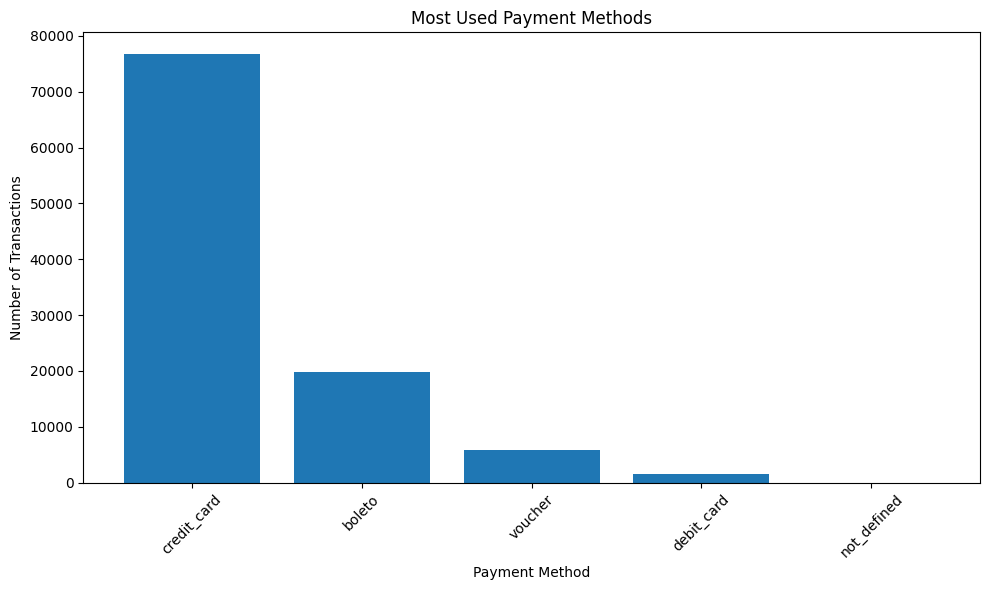

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    payment_method_analysis["payment_type"],
    payment_method_analysis["total_transactions"]
)

plt.title("Most Used Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Question 8: How well does Olist perform in delivering orders on time?**

In [ ]:
import pandas as pd

# 1. Ensure order-level sales columns exist
if "order_value" not in order_sales.columns:
    order_sales["order_value"] = (
        order_sales["product_sales"] + order_sales["total_freight"]
    ).round(2)

# 2. Add customer information to orders
order_summary = orders.merge(
    customers[
        ["customer_id", "customer_unique_id",
         "customer_city", "customer_state"]
    ],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

# 3. Add order-level sales
order_summary = order_summary.merge(
    order_sales,
    on="order_id",
    how="left",
    validate="one_to_one"
)

# 4. Add order-level payment information
order_summary = order_summary.merge(
    order_payments,
    on="order_id",
    how="left",
    validate="one_to_one"
)

# 5. Calculate the difference between payment and order value
order_summary["payment_difference"] = (
    order_summary["total_payment"] - order_summary["order_value"]
).round(2)

# 6. Validate the order summary
print("Order summary shape:", order_summary.shape)
print("Unique orders:", order_summary["order_id"].nunique())
print("Duplicate order IDs:", order_summary["order_id"].duplicated().sum())
print("Missing order values:", order_summary["order_value"].isna().sum())

# 7. Display the result
display(order_summary.head())

Order summary shape: (99441, 26)
Unique orders: 99441
Duplicate order IDs: 0
Missing order values: 775


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,delivery_days,...,customer_state,total_items,product_sales,total_freight,order_item_total,order_value,payment_count,total_payment,total_installments,payment_difference
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8.436574,...,SP,1.0,29.99,8.72,38.71,38.71,3.0,38.71,3.0,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,13.782037,...,BA,1.0,118.70,22.76,141.46,141.46,1.0,141.46,1.0,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,9.394213,...,GO,1.0,159.90,19.22,179.12,179.12,1.0,179.12,3.0,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,13.208750,...,RN,1.0,45.00,27.20,72.20,72.20,1.0,72.20,1.0,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2.873877,...,SP,1.0,19.90,8.72,28.62,28.62,1.0,28.62,1.0,0.0


**Question 8: How well does Olist perform in delivering orders on time?**

In [ ]:
# Filter delivered orders with valid delivery metrics
delivered_orders = order_summary[
    (order_summary["order_status"] == "delivered")
    & order_summary["delivery_days"].notna()
    & order_summary["delivery_delay_days"].notna()
].copy()

# Classify delivery performance
delivered_orders["delivery_category"] = (
    delivered_orders["delivery_delay_days"]
    .apply(lambda days: "On time or early" if days <= 0 else "Late")
)

# Summarize delivery performance
delivery_analysis = (
    delivered_orders
    .groupby("delivery_category", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_days_vs_estimate=("delivery_delay_days", "mean")
    )
)

# Calculate percentages
total_delivered = delivery_analysis["delivered_orders"].sum()

delivery_analysis["percentage"] = (
    delivery_analysis["delivered_orders"] / total_delivered * 100
).round(2)

# Round average values
delivery_analysis["avg_delivery_days"] = (
    delivery_analysis["avg_delivery_days"].round(2)
)

delivery_analysis["avg_days_vs_estimate"] = (
    delivery_analysis["avg_days_vs_estimate"].round(2)
)

# Display results
print("Total delivered orders analyzed:", total_delivered)
display(delivery_analysis)

Total delivered orders analyzed: 96470


,delivery_category,delivered_orders,avg_delivery_days,avg_days_vs_estimate,percentage
0,Late,7826,31.52,9.55,8.11
1,On time or early,88644,10.88,-13.01,91.89


**Validate the delivery results**

In [ ]:
# Verify delivery counts and percentages
print("Total delivered orders:", total_delivered)

delivery_analysis["calculated_percentage"] = (
    delivery_analysis["delivered_orders"] / total_delivered * 100
).round(2)

display(delivery_analysis)

print(
    "Sum of delivery categories:",
    delivery_analysis["delivered_orders"].sum()
)

Total delivered orders: 96470


,delivery_category,delivered_orders,avg_delivery_days,avg_days_vs_estimate,percentage,calculated_percentage
0,Late,7826,31.52,9.55,8.11,8.11
1,On time or early,88644,10.88,-13.01,91.89,91.89


Sum of delivery categories: 96470


**Visualize delivery performance**

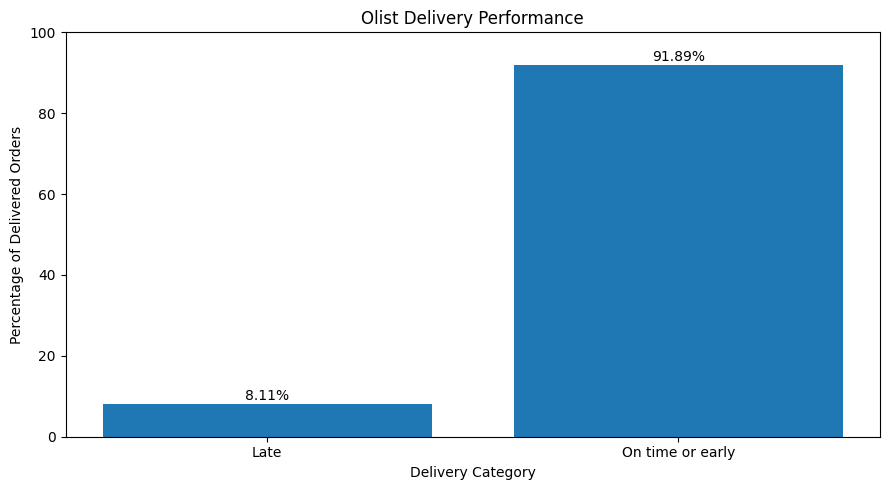

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    delivery_analysis["delivery_category"],
    delivery_analysis["percentage"]
)

plt.title("Olist Delivery Performance")
plt.xlabel("Delivery Category")
plt.ylabel("Percentage of Delivered Orders")
plt.ylim(0, 100)

for i, value in enumerate(delivery_analysis["percentage"]):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

**Question 9: Which product categories generate the highest revenue?**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Keep only delivered orders
delivered_order_ids = orders.loc[
    orders["order_status"] == "delivered",
    ["order_id"]
]

# 2. Join order items with delivered orders
category_sales = order_items.merge(
    delivered_order_ids,
    on="order_id",
    how="inner",
    validate="many_to_one"
)

# 3. Add product category
category_sales = category_sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left",
    validate="many_to_one"
)

# 4. Translate category names into English
category_sales = category_sales.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

# 5. Use English category names where available
category_sales["category"] = (
    category_sales["product_category_name_english"]
    .fillna(category_sales["product_category_name"])
    .fillna("Unknown")
)

# 6. Aggregate revenue by category
category_revenue = (
    category_sales
    .groupby("category", as_index=False)
    .agg(
        total_revenue=("price", "sum"),
        units_sold=("order_item_id", "count"),
        unique_orders=("order_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)

category_revenue["total_revenue"] = (
    category_revenue["total_revenue"].round(2)
)

print("Top 10 product categories by revenue:")
display(category_revenue.head(10))

Top 10 product categories by revenue:


,category,total_revenue,units_sold,unique_orders
44,health_beauty,1233131.72,9465,8647
73,watches_gifts,1166176.98,5859,5495
8,bed_bath_table,1023434.76,10953,9272
68,sports_leisure,954852.55,8431,7530
16,computers_accessories,888724.61,7644,6530
40,furniture_decor,711927.69,8160,6307
50,housewares,615628.69,6795,5743
21,cool_stuff,610204.10,3718,3559
6,auto,578966.65,4140,3810
72,toys,471286.48,4030,3804


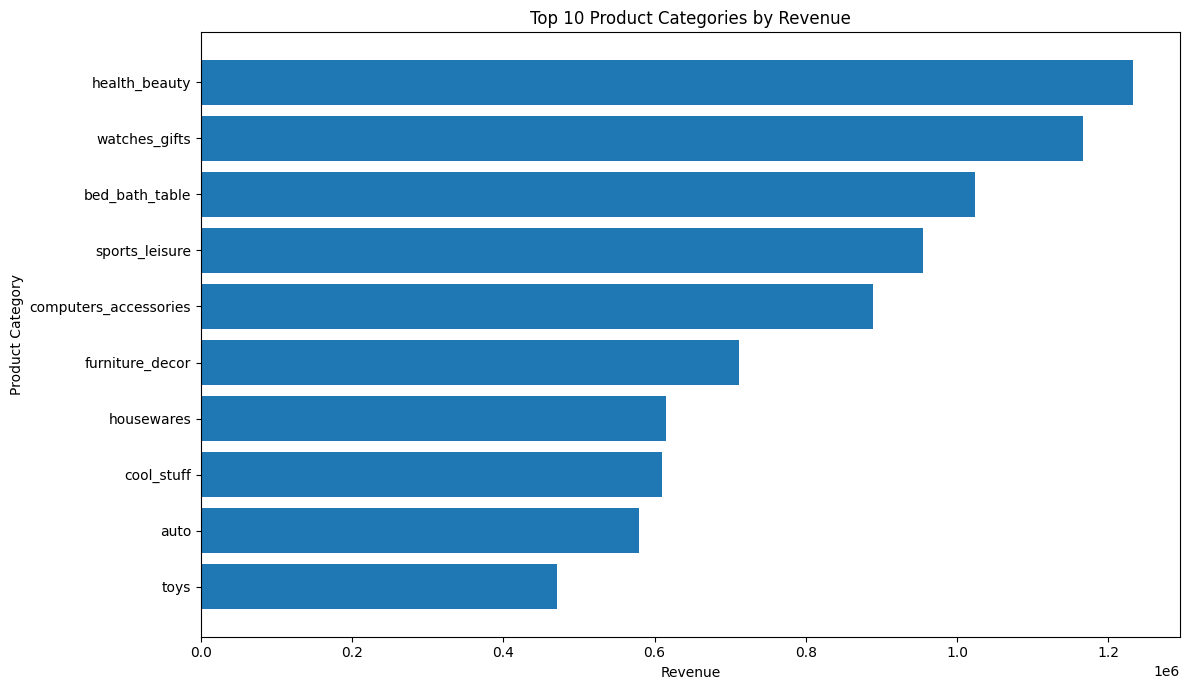

In [ ]:
top_categories = category_revenue.head(10).sort_values(
    "total_revenue",
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_categories["category"],
    top_categories["total_revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

**Question 10 — Which states generate the highest revenue?**

In [ ]:
import matplotlib.pyplot as plt

# Analyze delivered orders by customer state
state_sales = (
    order_summary[
        order_summary["order_status"] == "delivered"
    ]
    .groupby("customer_state", as_index=False)
    .agg(
        total_revenue=("product_sales", "sum"),
        total_orders=("order_id", "nunique"),
        unique_customers=("customer_unique_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)

state_sales["total_revenue"] = state_sales["total_revenue"].round(2)

print("Top 10 states by revenue:")
display(state_sales.head(10))

Top 10 states by revenue:


,customer_state,total_revenue,total_orders,unique_customers
25,SP,5067633.16,40501,39156
18,RJ,1759651.13,12350,11917
10,MG,1552481.83,11354,11001
22,RS,728897.47,5345,5168
17,PR,666063.51,4923,4769
23,SC,507012.13,3546,3449
4,BA,493584.14,3256,3158
6,DF,296498.41,2080,2019
8,GO,282836.70,1957,1895
7,ES,268643.45,1995,1928


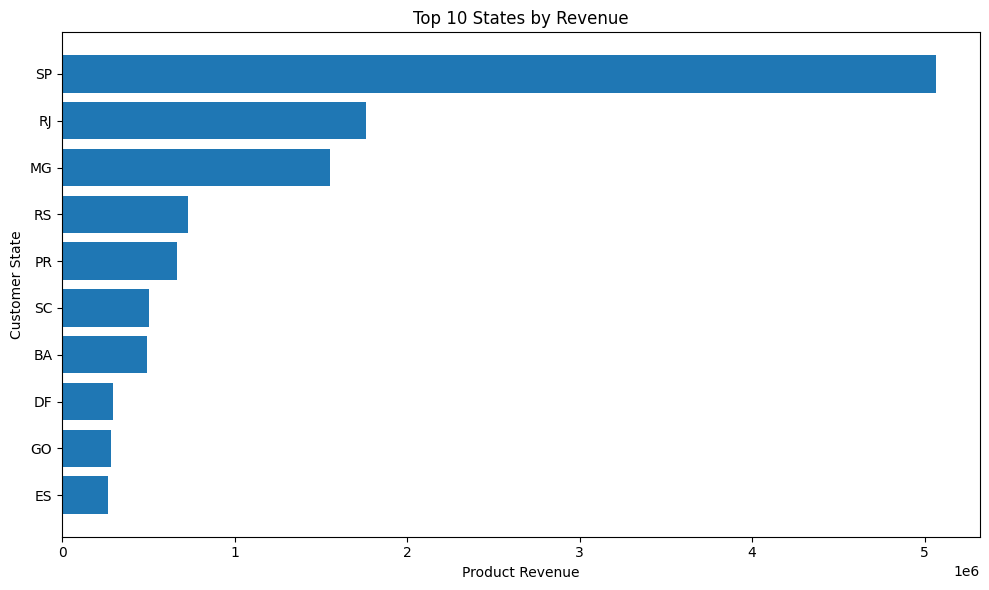

In [ ]:
top_states = state_sales.head(10).sort_values(
    "total_revenue",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_states["customer_state"],
    top_states["total_revenue"]
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Product Revenue")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

**Question 11 — How many customers make repeat purchases?**

In [ ]:
import pandas as pd

# Consider only delivered orders
delivered_orders = order_summary[
    order_summary["order_status"] == "delivered"
].copy()

# Count delivered orders per unique customer
customer_purchase_frequency = (
    delivered_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_spent=("product_sales", "sum")
    )
)

# Classify customers
customer_purchase_frequency["customer_type"] = (
    customer_purchase_frequency["total_orders"]
    .apply(lambda x: "Repeat Customer" if x > 1 else "One-time Customer")
)

# Summarize customer behavior
repeat_customer_analysis = (
    customer_purchase_frequency
    .groupby("customer_type", as_index=False)
    .agg(
        total_customers=("customer_unique_id", "nunique"),
        total_orders=("total_orders", "sum"),
        total_revenue=("total_spent", "sum")
    )
)

# Calculate customer percentages
total_customers = repeat_customer_analysis["total_customers"].sum()

repeat_customer_analysis["customer_percentage"] = (
    repeat_customer_analysis["total_customers"]
    / total_customers * 100
).round(2)

repeat_customer_analysis["total_revenue"] = (
    repeat_customer_analysis["total_revenue"].round(2)
)

display(repeat_customer_analysis)

,customer_type,total_customers,total_orders,total_revenue,customer_percentage
0,One-time Customer,90557,90557,12493089.36,97.0
1,Repeat Customer,2801,5921,728408.75,3.0


**Question 12 — What is the average order value (AOV)?**

In [ ]:
# Consider only delivered orders
delivered_orders = order_summary[
    order_summary["order_status"] == "delivered"
].copy()

# Calculate key revenue metrics
total_revenue = delivered_orders["order_value"].sum()
total_orders = delivered_orders["order_id"].nunique()

average_order_value = total_revenue / total_orders

print(f"Total delivered orders: {total_orders:,}")
print(f"Total revenue including freight: {total_revenue:,.2f}")
print(f"Average Order Value (AOV): {average_order_value:,.2f}")

Total delivered orders: 96,478
Total revenue including freight: 15,419,773.75
Average Order Value (AOV): 159.83


**Question 13 — How does revenue change month by month?**

**Monthly revenue analysis**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter delivered orders
delivered_orders = order_summary[
    order_summary["order_status"] == "delivered"
].copy()

# Aggregate monthly performance
monthly_analysis = (
    delivered_orders
    .groupby("purchase_month", as_index=False)
    .agg(
        total_revenue=("order_value", "sum"),
        total_orders=("order_id", "nunique"),
        unique_customers=("customer_unique_id", "nunique")
    )
    .sort_values("purchase_month")
)

# Calculate monthly average order value
monthly_analysis["average_order_value"] = (
    monthly_analysis["total_revenue"]
    / monthly_analysis["total_orders"]
).round(2)

monthly_analysis["total_revenue"] = (
    monthly_analysis["total_revenue"].round(2)
)

print("Monthly revenue analysis:")
display(monthly_analysis)

Monthly revenue analysis:


,purchase_month,total_revenue,total_orders,unique_customers,average_order_value
0,2016-09,143.46,1,1,143.46
1,2016-10,46490.66,265,262,175.44
2,2016-12,19.62,1,1,19.62
3,2017-01,127482.37,750,718,169.98
4,2017-02,271239.32,1653,1630,164.09
5,2017-03,414330.95,2546,2508,162.74
6,2017-04,390812.40,2303,2274,169.70
7,2017-05,566851.40,3546,3479,159.86
8,2017-06,490050.37,3135,3076,156.32
9,2017-07,566299.08,3872,3802,146.25


**Visualize the monthly revenue trend**

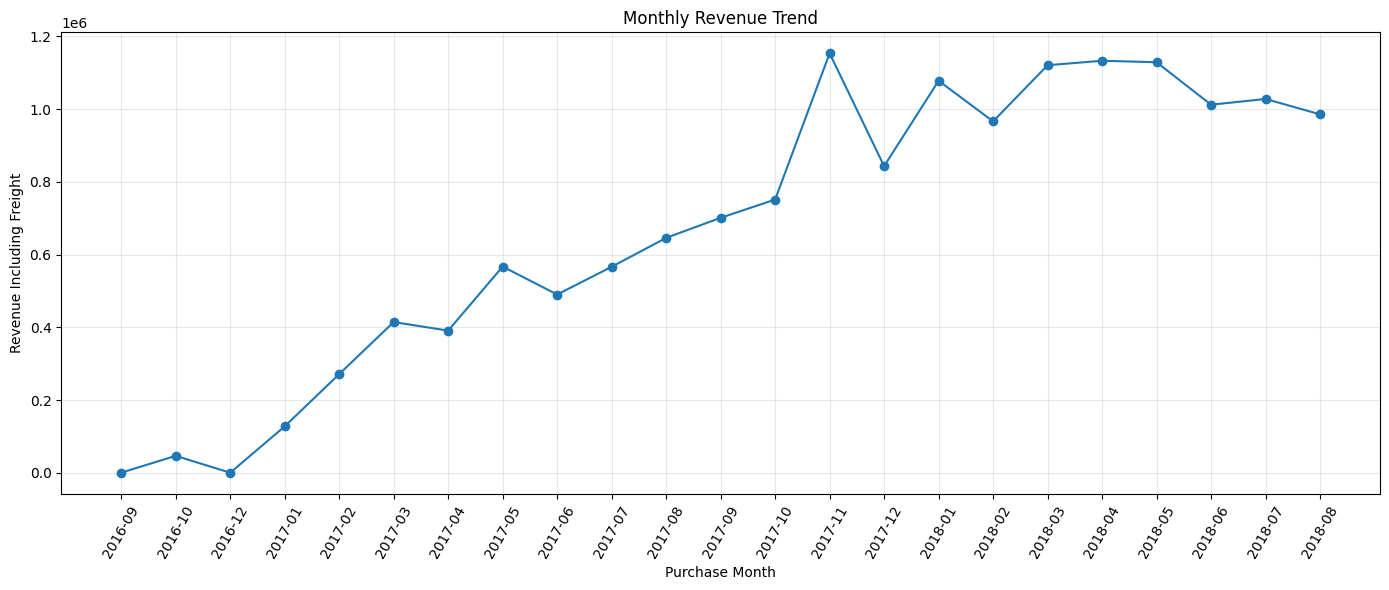

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["purchase_month"],
    monthly_analysis["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Revenue Including Freight")
plt.xticks(rotation=60)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Identify the highest and lowest revenue months**

In [ ]:
highest_month = monthly_analysis.loc[
    monthly_analysis["total_revenue"].idxmax()
]

lowest_month = monthly_analysis.loc[
    monthly_analysis["total_revenue"].idxmin()
]

print(
    f"Highest revenue month: {highest_month['purchase_month']} "
    f"({highest_month['total_revenue']:,.2f})"
)

print(
    f"Lowest revenue month: {lowest_month['purchase_month']} "
    f"({lowest_month['total_revenue']:,.2f})"
)

Highest revenue month: 2017-11 (1,153,364.20)
Lowest revenue month: 2016-12 (19.62)


**Question 14 — How satisfied are customers with their purchases?**

**Analyze customer review scores**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Review score distribution
review_score_analysis = (
    reviews
    .groupby("review_score", as_index=False)
    .agg(
        total_reviews=("review_id", "count")
    )
    .sort_values("review_score")
)

# 2. Calculate review percentages
total_reviews = review_score_analysis["total_reviews"].sum()

review_score_analysis["percentage"] = (
    review_score_analysis["total_reviews"] / total_reviews * 100
).round(2)

# 3. Calculate overall average review score
average_review_score = reviews["review_score"].mean()

print(f"Total reviews: {total_reviews:,}")
print(f"Average review score: {average_review_score:.2f} / 5")

display(review_score_analysis)

Total reviews: 99,224
Average review score: 4.09 / 5


,review_score,total_reviews,percentage
0,1,11424,11.51
1,2,3151,3.18
2,3,8179,8.24
3,4,19142,19.29
4,5,57328,57.78


**Visualize the review score distribution**

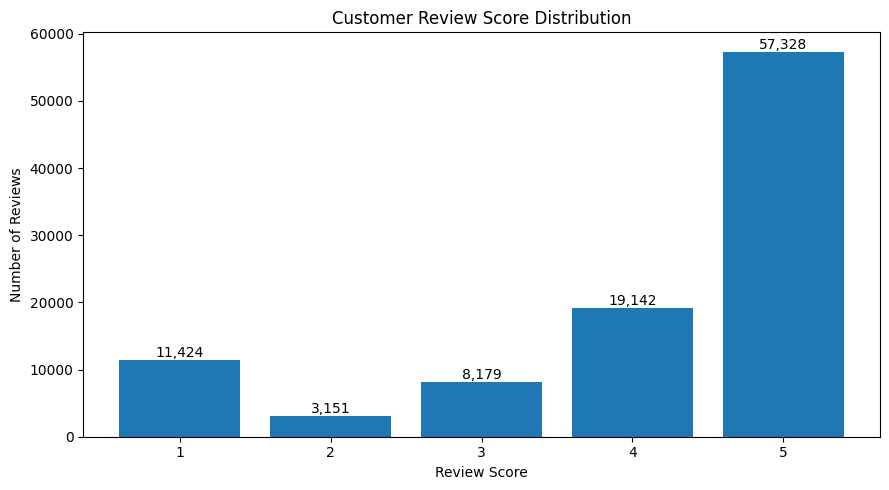

In [ ]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    review_score_analysis["review_score"].astype(str),
    review_score_analysis["total_reviews"]
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Calculate positive and negative review percentages**

In [ ]:
positive_reviews = reviews["review_score"].isin([4, 5]).sum()
neutral_reviews = (reviews["review_score"] == 3).sum()
negative_reviews = reviews["review_score"].isin([1, 2]).sum()

print(f"Positive reviews (4–5): {positive_reviews:,}")
print(f"Positive review percentage: {positive_reviews / total_reviews * 100:.2f}%")

print(f"Neutral reviews (3): {neutral_reviews:,}")
print(f"Neutral review percentage: {neutral_reviews / total_reviews * 100:.2f}%")

print(f"Negative reviews (1–2): {negative_reviews:,}")
print(f"Negative review percentage: {negative_reviews / total_reviews * 100:.2f}%")

Positive reviews (4–5): 76,470
Positive review percentage: 77.07%
Neutral reviews (3): 8,179
Neutral review percentage: 8.24%
Negative reviews (1–2): 14,575
Negative review percentage: 14.69%


**Question 15 — Do late deliveries lead to lower review scores?**

In [ ]:
import pandas as pd

# 1. Select relevant order and review columns
delivery_reviews = order_summary[
    [
        "order_id",
        "order_status",
        "delivery_delay_days"
    ]
].merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner",
    validate="one_to_many"
)

# 2. Keep delivered orders with valid delivery information
delivery_reviews = delivery_reviews[
    (delivery_reviews["order_status"] == "delivered")
    & delivery_reviews["delivery_delay_days"].notna()
].copy()

# 3. Classify delivery performance
delivery_reviews["delivery_category"] = (
    delivery_reviews["delivery_delay_days"]
    .apply(lambda days: "Late" if days > 0 else "On time or early")
)

# 4. Summarize review scores
delivery_review_analysis = (
    delivery_reviews
    .groupby("delivery_category", as_index=False)
    .agg(
        total_reviews=("review_score", "count"),
        average_review_score=("review_score", "mean"),
        low_rating_reviews=(
            "review_score",
            lambda scores: scores.isin([1, 2]).sum()
        )
    )
)

# 5. Calculate the percentage of low ratings
delivery_review_analysis["low_rating_percentage"] = (
    delivery_review_analysis["low_rating_reviews"]
    / delivery_review_analysis["total_reviews"]
    * 100
).round(2)

delivery_review_analysis["average_review_score"] = (
    delivery_review_analysis["average_review_score"].round(2)
)

display(delivery_review_analysis)

,delivery_category,total_reviews,average_review_score,low_rating_reviews,low_rating_percentage
0,Late,7700,2.57,4160,54.03
1,On time or early,88653,4.29,8186,9.23


**Question 16 — Which order statuses are most common?**

**Analyze order status**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Count orders by status
order_status_analysis = (
    orders
    .groupby("order_status", as_index=False)
    .agg(
        total_orders=("order_id", "nunique")
    )
    .sort_values("total_orders", ascending=False)
)

# Calculate percentages
total_orders = order_status_analysis["total_orders"].sum()

order_status_analysis["percentage"] = (
    order_status_analysis["total_orders"] / total_orders * 100
).round(2)

print(f"Total orders: {total_orders:,}")
display(order_status_analysis)

Total orders: 99,441


,order_status,total_orders,percentage
3,delivered,96478,97.02
6,shipped,1107,1.11
1,canceled,625,0.63
7,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
2,created,5,0.01
0,approved,2,0.00


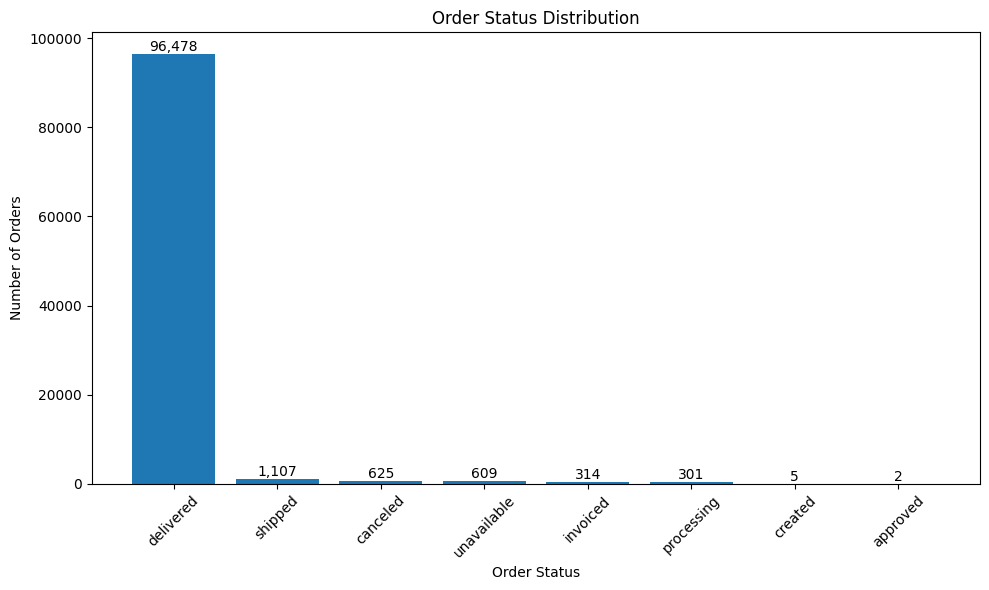

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    order_status_analysis["order_status"],
    order_status_analysis["total_orders"]
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

for i, value in enumerate(order_status_analysis["total_orders"]):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

**Question 17 — Which sellers generate the most revenue?**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identify delivered orders
delivered_order_ids = orders.loc[
    orders["order_status"] == "delivered",
    ["order_id"]
]

# 2. Keep items belonging to delivered orders
seller_sales = order_items.merge(
    delivered_order_ids,
    on="order_id",
    how="inner",
    validate="many_to_one"
)

# 3. Aggregate performance by seller
seller_analysis = (
    seller_sales
    .groupby("seller_id", as_index=False)
    .agg(
        total_revenue=("price", "sum"),
        units_sold=("order_item_id", "count"),
        unique_orders=("order_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)

seller_analysis["total_revenue"] = (
    seller_analysis["total_revenue"].round(2)
)

print("Top 10 sellers by revenue:")
display(seller_analysis.head(10))

Top 10 sellers by revenue:


,seller_id,total_revenue,units_sold,unique_orders
834,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1148,1124
982,53243585a1d6dc2643021fd1853d8905,217940.44,400,348
858,4a3ca9315b744ce9f8e9374361493884,196882.12,1949,1772
2903,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,579,578
1480,7c67e1448b00f6e969d365cea6b010ab,186570.05,1355,973
1504,7e93a43ef30c4f03f38b393420bc753a,165981.49,322,319
2543,da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1548,1311
1450,7a67c85e85bb2ce8582c35f2203ad736,139658.69,1155,1145
188,1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,1420,910
1758,955fee9216a65b617aa5c0531780ce60,131836.71,1472,1261


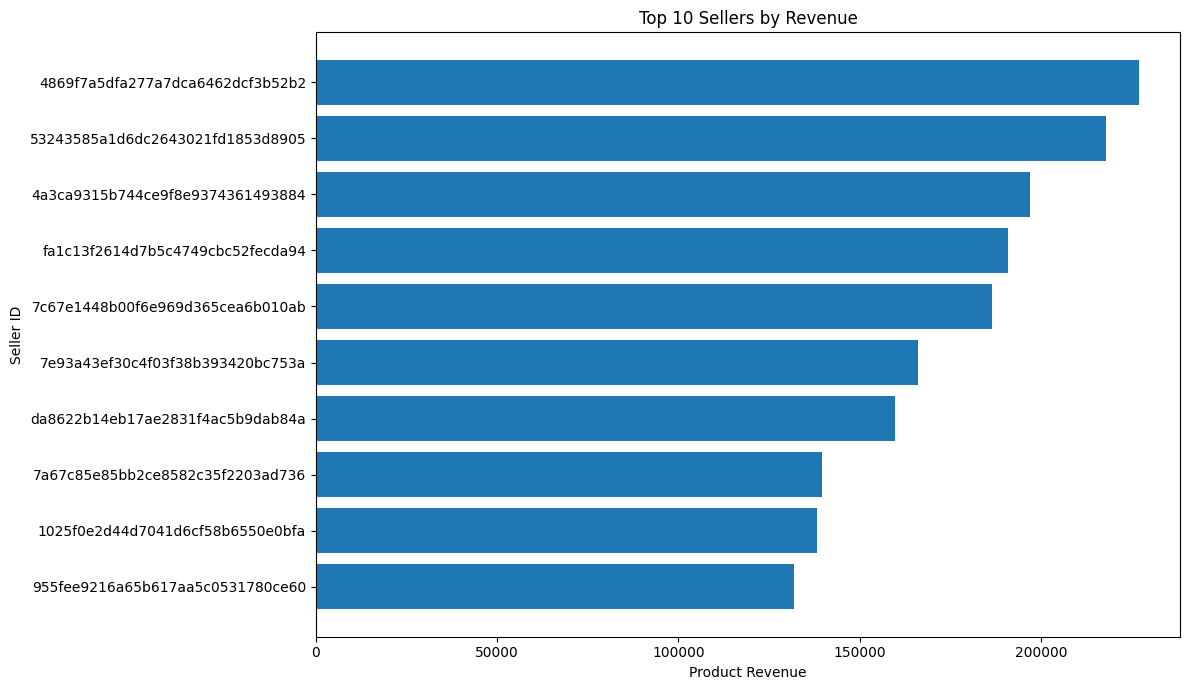

In [ ]:
top_sellers = seller_analysis.head(10).sort_values(
    "total_revenue",
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_sellers["seller_id"],
    top_sellers["total_revenue"]
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Product Revenue")
plt.ylabel("Seller ID")
plt.tight_layout()
plt.show()

**Export all analysis results**

In [ ]:
import os
import zipfile
from google.colab import files

# Create an output folder
output_dir = "/content/olist_analysis_results"
os.makedirs(output_dir, exist_ok=True)

# Collect all analysis results
analysis_tables = {
    "payment_method_analysis": payment_method_analysis,
    "delivery_analysis": delivery_analysis,
    "category_revenue": category_revenue,
    "state_sales": state_sales,
    "repeat_customer_analysis": repeat_customer_analysis,
    "monthly_analysis": monthly_analysis,
    "review_score_analysis": review_score_analysis,
    "delivery_review_analysis": delivery_review_analysis,
    "order_status_analysis": order_status_analysis,
    "seller_analysis": seller_analysis
}

# Export each table
for name, df in analysis_tables.items():
    df.to_csv(
        os.path.join(output_dir, f"{name}.csv"),
        index=False
    )

    print(f"Exported: {name}.csv | Rows: {len(df)}")

# Create a ZIP file
zip_path = "/content/olist_analysis_results.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for filename in os.listdir(output_dir):
        file_path = os.path.join(output_dir, filename)
        zipf.write(file_path, arcname=filename)

print("\nAll analysis results exported successfully!")
files.download(zip_path)

Exported: payment_method_analysis.csv | Rows: 5
Exported: delivery_analysis.csv | Rows: 2
Exported: category_revenue.csv | Rows: 74
Exported: state_sales.csv | Rows: 27
Exported: repeat_customer_analysis.csv | Rows: 2
Exported: monthly_analysis.csv | Rows: 23
Exported: review_score_analysis.csv | Rows: 5
Exported: delivery_review_analysis.csv | Rows: 2
Exported: order_status_analysis.csv | Rows: 8
Exported: seller_analysis.csv | Rows: 2970

All analysis results exported successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>